In [32]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error

from data import CaseVFL

In [2]:
N = 1000
feature_count = 100
parties = 5

party_size = feature_count // parties
assert party_size * parties == feature_count

rng = np.random.default_rng(42)
case = CaseVFL(
    rng = rng,
    n = N,
    events = feature_count,
    output_arity = 50,
    sensors = parties,
    sensor_arity = party_size,
    noise_std = 0.01
)

X_train, Y_train = case.generate_data()
X_test, Y_test = case.generate_data()
X_train_agg = np.block([x.T for x in X_train])
X_test_agg = np.block([x.T for x in X_test])

# Baseline

In [3]:
model = Ridge(alpha=0.05).fit(X_train_agg, Y_train)
Y_train_pred = model.predict(X_train_agg)
print(f"Train Error: {mean_squared_error(Y_train_pred, Y_train)}")
Y_test_pred = model.predict(X_test_agg)
print(f"Test Error: {mean_squared_error(Y_test_pred, Y_test)}")

Train Error: 8.745205646168433e-05
Test Error: 0.00011756193048215462


# VFL

In [57]:
weights = [rng.uniform(size=(party_size)) for _ in range(parties)]
for iteration in range(300000):
    Y_hat = np.sum([(weights[i] @ X_train[i]) for i in range(parties)], axis=0)
    eta = 1 / 10000
    for i in range(parties):
        weights[i] -= (X_train[i] @ (Y_hat - Y_train)) * 2 / N * eta

Y_train_hat = np.sum([(weights[i] @ X_train[i]) for i in range(parties)], axis=0)
print("Train", mean_squared_error(Y_train_hat, Y_train))
Y_test_hat = np.sum([(weights[i] @ X_test[i]) for i in range(parties)], axis=0)
print("Test", mean_squared_error(Y_test_hat, Y_test))

Train 9.016817380303679e-05
Test 0.0001197005474922649


In [68]:
train_errors = []
test_errors = []
ks = [1, 2, 3]

for k in ks:
    print(f"k={k}")
    weights = [rng.uniform(size=(party_size)) for _ in range(parties)]
    global_weights = [w.copy() for w in weights]
    eta = 1 / 5000
    
    for iteration in range(100000):
        for i in range(parties):
            Y_hat_i = np.sum([
                (weights[i] @ X_train[i]) if j == i else (global_weights[j] @ X_train[j])
                for j in range(parties)
            ], axis=0)
            weights[i] -= (X_train[i] @ (Y_hat_i - Y_train)) * 2 / N * eta
    
        if (iteration + 1) % k == 0:
            global_weights = [w.copy() for w in weights]
            
    Y_train_hat = np.sum([(weights[i] @ X_train[i]) for i in range(parties)], axis=0)
    Y_test_hat = np.sum([(weights[i] @ X_test[i]) for i in range(parties)], axis=0)
    train_errors.append(mean_squared_error(Y_train_hat, Y_train))
    test_errors.append(mean_squared_error(Y_test_hat, Y_test))

k=1
k=2


/tmp/ipykernel_240577/591424071.py:17: RuntimeWarning: overflow encountered in multiply
  weights[i] -= (X_train[i] @ (Y_hat_i - Y_train)) * 2 / N * eta
/tmp/ipykernel_240577/591424071.py:17: RuntimeWarning: invalid value encountered in matmul
  weights[i] -= (X_train[i] @ (Y_hat_i - Y_train)) * 2 / N * eta
/tmp/ipykernel_240577/591424071.py:17: RuntimeWarning: invalid value encountered in subtract
  weights[i] -= (X_train[i] @ (Y_hat_i - Y_train)) * 2 / N * eta


KeyboardInterrupt: 

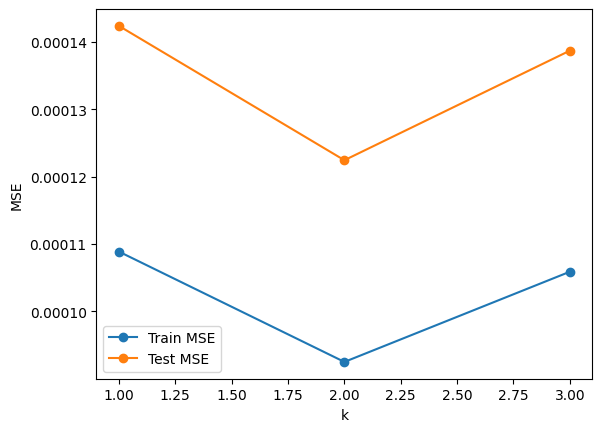

In [62]:
fig, ax = plt.subplots()
ax.plot(ks, train_errors, marker='o', label='Train MSE')
ax.plot(ks, test_errors, marker='o', label='Test MSE')
ax.set_xlabel('k')
ax.set_ylabel('MSE')
ax.legend()
plt.savefig("figures/fgd_delay.png")
plt.show()

# Gradient Inversion

In [10]:
T = 100000
X_atk, Y_atk = case.generate_data()
weights = [rng.uniform(size=(party_size)) for _ in range(parties)]
gradients = []

for iteration in range(T):
    grad = [(weights[i] @ X_train[i]) for i in range(parties)]
    Y_hat = np.sum(grad, axis=0)
    gradients.append(grad)
    eta = 1 / 10000
    for i in range(parties):
        weights[i] -= (X_train[i] @ (Y_hat - Y_train)) * 2 / N * eta

In [12]:
Y_atk_hat = np.sum([(weights[i] @ X_atk[i]) for i in range(parties)], axis=0)
print("Train", mean_squared_error(Y_atk_hat, Y_atk))

Train 0.0009679335561469695


In [27]:
recovered_features = []
recovered_weights = []
for p in range(parties):
    G = np.vstack([gradients[t][p] for t in range(T//50)]).T
    U, S, Vt = np.linalg.svd(G, full_matrices=False)

    # restrict to relevant values
    r = np.sum(S > 1e-10)
    U_r = U[:,:r]
    S_r = S[:r]
    V_r = Vt[:r,:].T
    print(r)

    # weights_r = (np.diag(S_r) @ V_r.T).mean(axis=1)
    weights_r = (np.diag(S_r) @ V_r.T)[:,-1]
    
    recovered_features.append(U_r)
    recovered_weights.append(weights_r)
Y_hat = sum(recovered_features[p] @ recovered_weights[p] for p in range(parties))
mean_squared_error(Y_hat, Y_atk)

20
20
20
19
20


2528.324770041841

In [29]:
r_values = {p: [] for p in range(parties)}
intervals = [1, 5, 10, 50, 100, 500, 1000, 5000, 10000]
for interval in intervals:
    for p in range(parties):
        G = np.vstack([gradients[t][p] for t in range(T//interval)]).T
        U, S, Vt = np.linalg.svd(G, full_matrices=False)
        r = np.sum(S > 1e-10)
        print(interval, p, r)
        r_values[p].append(r)

1 0 21
1 1 20
1 2 22
1 3 20
1 4 20
5 0 20
5 1 20
5 2 20
5 3 20
5 4 20
10 0 20
10 1 20
10 2 20
10 3 20
10 4 20
50 0 20
50 1 20
50 2 20
50 3 19
50 4 20
100 0 17
100 1 17
100 2 17
100 3 17
100 4 17
500 0 12
500 1 12
500 2 12
500 3 12
500 4 12
1000 0 10
1000 1 10
1000 2 10
1000 3 10
1000 4 10
5000 0 8
5000 1 8
5000 2 8
5000 3 8
5000 4 8
10000 0 7
10000 1 7
10000 2 7
10000 3 7
10000 4 7


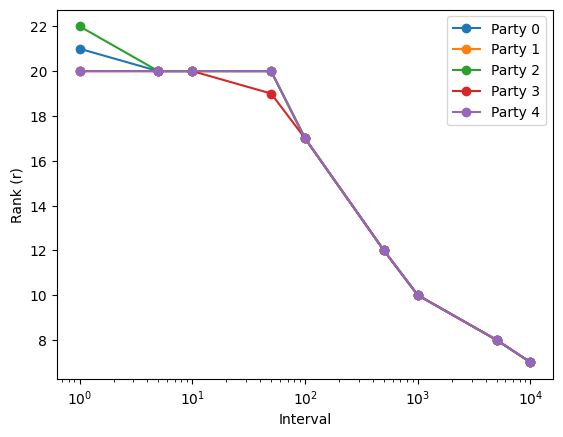

In [34]:
fig, ax = plt.subplots()
for p in range(parties):
    ax.plot(intervals, r_values[p], marker='o', label=f'Party {p}')
ax.set_xscale('log')
ax.set_xlabel('Interval')
ax.set_ylabel('Rank (r)')
ax.legend()
plt.savefig("figures/gia_rank.png")
plt.show()

In [192]:
"""
Federated GD: https://dl.acm.org/doi/pdf/10.1145/1281192.1281275
Cocktail Party: https://arxiv.org/pdf/2209.05578
CAFE: https://arxiv.org/pdf/2110.15122 (new gradient inversion tech)
Gradient Inversion Survey: https://arxiv.org/pdf/2206.07284
"""

'\nFederated GD: https://dl.acm.org/doi/pdf/10.1145/1281192.1281275\nCocktail Party: https://arxiv.org/pdf/2209.05578\nCAFE: https://arxiv.org/pdf/2110.15122 (new gradient inversion tech)\nSurvey: https://arxiv.org/pdf/2206.07284\n'